In [1]:
from collections import defaultdict
import logging

import jax

import random

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

# Setup

We train a linear model and observe the training dynamics wrt the learning rate η for fixed -
 
- batch size $B$ or 
- *temperature* given by $\frac{\eta}{B}$.


In [2]:
from batch_size_studies.configs import get_main_experiment_configs, get_main_hyperparameter_grids
from batch_size_studies.checkpoint_utils import load_final_weights_for_experiment
from batch_size_studies.data_utils import (
    filter_loss_dicts,
    moving_average,
    sample_aware_smooth_loss_dicts,
    extract_loss_histories,
    filter_loss_dict_by_cutoff,
    subsample_loss_dict_periodic,
    filter_experiments,
)

from batch_size_studies.definitions import RunKey, LossType, OptimizerType
from batch_size_studies.experiments import (
    Parameterization,
    SyntheticExperimentFixedData,
    SyntheticExperimentFixedTime,
    MNIST1MExperiment,
    MNIST1MSampledExperiment,
)

from batch_size_studies.data_utils import filter_loss_dict_by_loss_threshold
from batch_size_studies.plotting_utils import plot_heatmap_with_theory_curve, plot_loss_curves, plot_loss_heatmap, plot_all_loss_curves

from batch_size_studies.runner import run_experiment_sweep

## Hyperparameters for sweeps

In [3]:
all_experiments = get_main_experiment_configs()
batch_sizes, etas = get_main_hyperparameter_grids()

print(f"There are {len(batch_sizes)} batch sizes:")
print(batch_sizes)

print(f"\n There are {len(etas)} learning rates:")
print([f"{eta:.0e}" for eta in etas])

There are 17 batch sizes:
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]

 There are 26 learning rates:
['2e-04', '5e-04', '1e-03', '2e-03', '4e-03', '8e-03', '2e-02', '3e-02', '6e-02', '1e-01', '2e-01', '5e-01', '1e+00', '2e+00', '4e+00', '8e+00', '2e+01', '3e+01', '6e+01', '1e+02', '3e+02', '5e+02', '1e+03', '2e+03', '4e+03', '8e+03']


In [4]:
all_temps = np.unique(np.array(etas)[:, np.newaxis] / np.array(batch_sizes))
print(
    f"Temperatures are in the range [2^{round(np.log2(all_temps).min())}, 2^{round(np.log2(all_temps).max())}], logarithmically spaced."
)

Temperatures are in the range [2^-28, 2^13], logarithmically spaced.


## Smoothing

To treat runs wtih different batch sizes (and hence less iterations) together, we smooth the loss curve in sample space, i.e. the window of the moving average depends on the batch size

In [5]:
MOVING_AVG_SAMPLES_WINDOW = 100

rk_smoother = lambda rk, loss_history: moving_average(
    loss_history, max(round(MOVING_AVG_SAMPLES_WINDOW / rk.batch_size), 1)
)

# Linear Model

In [6]:
from batch_size_studies.experiments import SyntheticExperimentLinearTeacher

In [7]:
EXPERIMENT_TYPE = SyntheticExperimentLinearTeacher


OPTIMIZER = OptimizerType.SGD
LOSS_TYPE = LossType.MSE

In [8]:
experiments = filter_experiments(all_experiments, EXPERIMENT_TYPE, loss_type=LOSS_TYPE, optimizer=OPTIMIZER)
for k in experiments.keys():
    print(k)

linear_teacher_P1048576_epochs1
noisy_linear_teacher_P1048576_epochs1_rho0p25
noisy_linear_teacher_P1048576_epochs1_rho0p6
linear_teacher_P131072_epochs8
noisy_linear_teacher_P131072_epochs8_rho0p25
noisy_linear_teacher_P131072_epochs8_rho0p6
linear_teacher_P1024_epochs1024
noisy_linear_teacher_P1024_epochs1024_rho0p25
noisy_linear_teacher_P1024_epochs1024_rho0p6


The names of the experiments should follow the convention:

 `<task>_<parameterization>_<loss_fn_type>_<optimizer>_<gamma_value>`


Each experiment object is a Dataclass with all relevant parameters for training dynamics specified. Let's look at one.

In [9]:
random_experiment = random.choice(list(experiments.values()))
random_experiment.describe()

SyntheticExperimentNoisyLinearTeacher(optimizer=<OptimizerType.SGD: 'SGD'>,
                                      loss_type=<LossType.MSE: 'MSE'>,
                                      experiment_type='fixed_data_noisy_linear_teacher',
                                      D=500,
                                      P=131072,
                                      alpha=2.0,
                                      beta=0.25,
                                      num_epochs=8,
                                      seed=0,
                                      rho=0.6)


In [10]:
loss_dicts = defaultdict(dict)
fails_dicts = defaultdict(dict)

In [11]:
import logging
logging.getLogger().setLevel(logging.INFO)  # this gives more descriptive logs when runs are skipped


for exp_name, e in experiments.items():
    results_obj, failed_runs = run_experiment_sweep(
        e, batch_sizes, etas
    )  # second is failed_runs, which is the set of RunKeys (batch, eta) that have diverged in prior experiments ran
    loss_dicts[exp_name] = results_obj
    fails_dicts[exp_name] = failed_runs

INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.


The `results_obj` object, loaded from an experiment's results file, is a Python dictionary that maps each hyperparameter trial to its outcome.

*   **Keys**: The keys of the dictionary are `RunKey` objects. A `RunKey` is a lightweight object that uniquely identifies a single training run by its core hyperparameters, which are `batch_size` and `eta` (learning rate).
    *   *Example*: `RunKey(batch_size=64, eta=0.01)`

*   **Values**: The values are dictionaries containing the metrics for that specific run. Common keys in this inner dictionary include:
    *   `'loss_history'`: A list of loss values recorded during training.
    *   `'epoch'`: The total number of complete epochs completed during the training run. 
    *   `'expected_steps'`: The total number of training steps the run was configured to execute. It's useful for verification; if len(loss_history) is less than expected_steps, it indicates that the run terminated prematurely
    *   `'final_eval_loss'`: The final test accuracy representing the model's performance on the unseen evaluation (test) dataset after the training loop has completed. 

    **NB!** Earlier bug used wrong data for 'final_eval_loss' so older (pickled) runs have this value wrong, and should **not** be trusted. In this notebook we manually compute the test values.


In [12]:
results_obj[RunKey(batch_size=1, eta=0.5)].keys()

dict_keys(['loss_history', 'epoch', 'expected_steps', 'final_eval_loss'])

## Heatmaps


Extract the sufficient statistics for our bounds, namely

- $\lambda_{max}$
- $\mathrm{Tr}(\Sigma)$

Currently, we have a 
- lower bound, i.e. "guaranteed convergence" given by 
$$\frac{2}{\lambda_{max}(1 + 1/b) +\mathrm{Tr}(\Sigma) /b},$$
where $b$ is the batch size.

- critical batch size, i.e. transition of temp-bounded to Hessian-bounded:
$$b_{crit} := \frac{\mathrm{Tr}(\Sigma)}{\lambda_{max}}$$

In [13]:
# These are the theoretical values
lambda_max_val = 1.
tr_sigma_val = np.sum(np.arange(1., random_experiment.D) ** -random_experiment.alpha)

print(f'Max eigenvalues: {lambda_max_val}, and trace: {tr_sigma_val:3f}')

Max eigenvalues: 1.0, and trace: 1.642932


Alternatively, one could extract them from the data (uncomment below). All experiments have same α and β and D, so we can just pick one.

In [14]:
# from batch_size_studies.hessian_evaluator import HessianEvaluator

# evaluator = HessianEvaluator(
#     experiment=random_experiment,
#     run_key=None,  # stay at initialization
#     step=None,
#     # directory="experiments", # or your custom sweep directory
#     num_hessian_samples=1024,
#     hessian_batch_size=128,
# )

# eigvals, eigvecs = evaluator.top_eigenvalues(top_n=1)
# lambda_max = eigvals[0]
# trace_val = evaluator.trace(max_iter=100)

# print(f'Max eigenvalues: {lambda_max.item()}, and trace: {trace_val.item():3f}')

In [15]:
# Computing the relevant quantities. Note lower_bound is a callable, while crit_batch is a float.

lower_bound = lambda b: 2 / (lambda_max_val * (1 + 1 / b) + tr_sigma_val / b)
crit_batch = tr_sigma_val / lambda_max_val

Plotting the heatmaps of last (smoothed) training loss for all experiments.

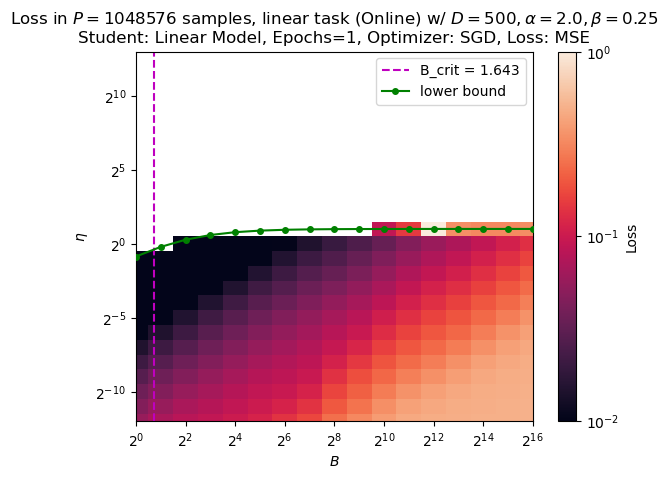

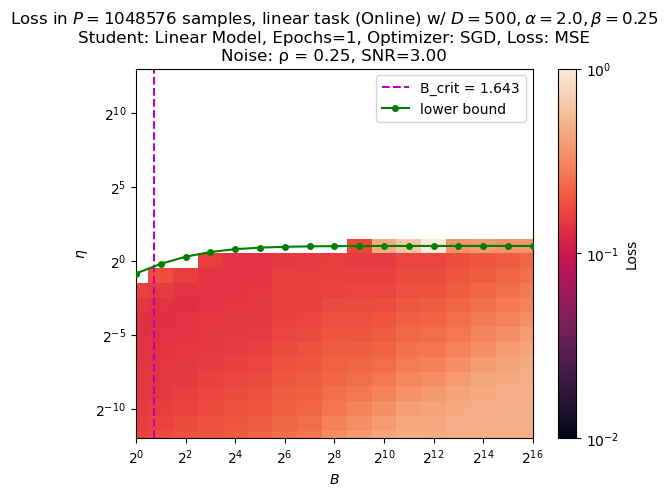

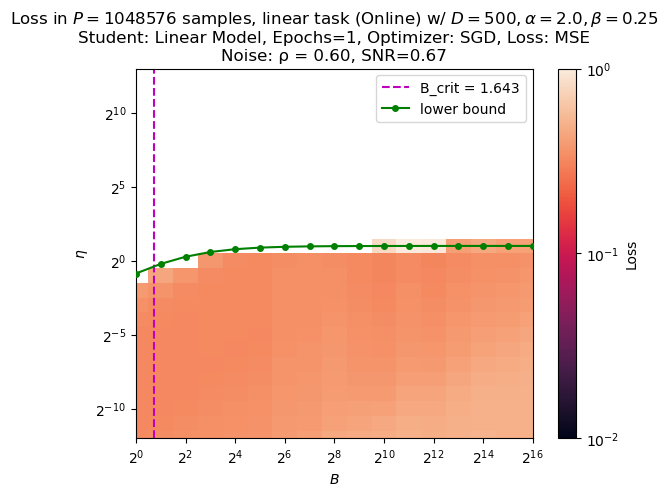

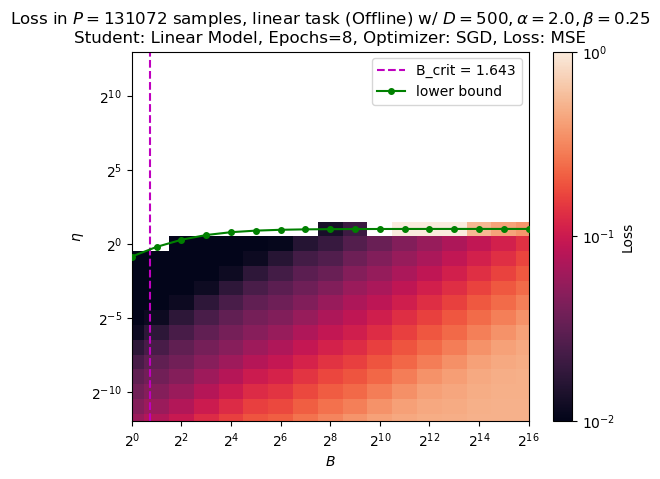

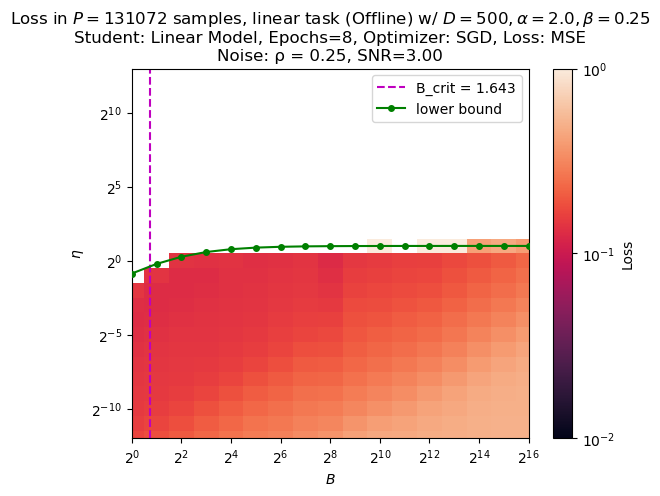

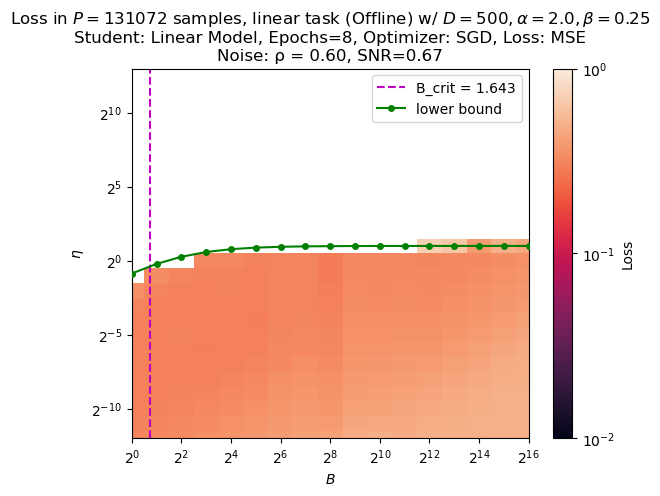

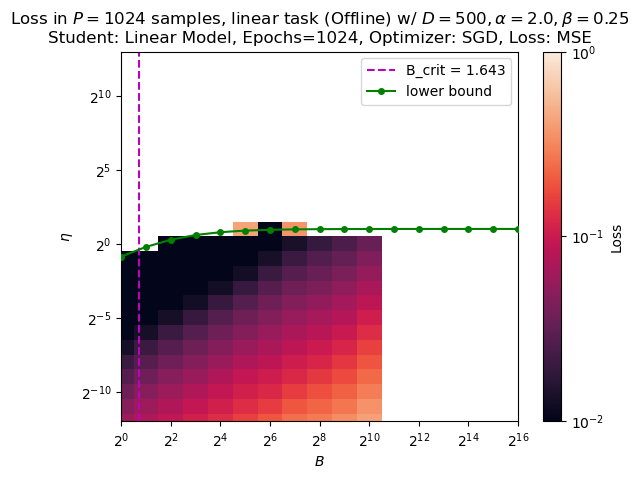

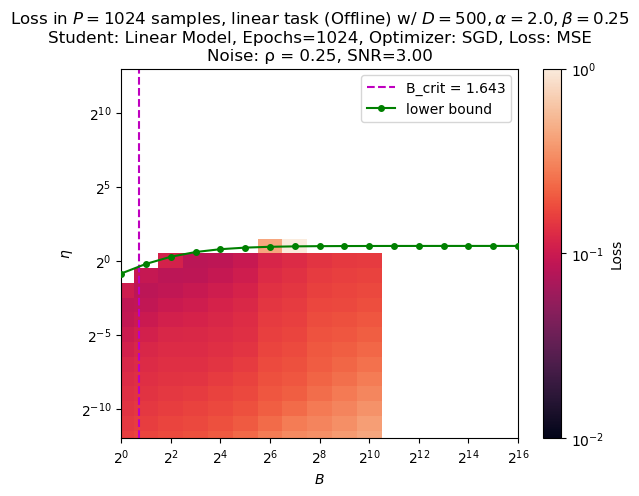

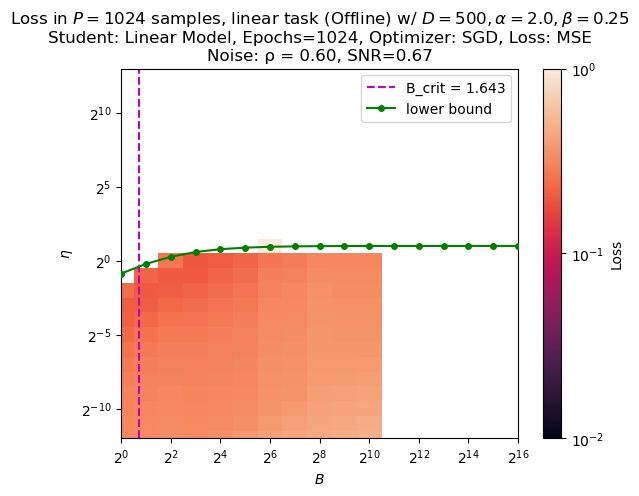

In [16]:
for e_name, experiment in experiments.items():
    loss_dict = loss_dicts[e_name]
    # Filter out all runs where loss exceeds 100 at any point
    loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)
    plot_heatmap_with_theory_curve(
        sample_aware_smooth_loss_dicts(loss_dict, rk_smoother), # or `loss_dict` if no smoothing,
        batch_sizes,
        etas,
        experiment.plot_title(),
        lower_bound=lower_bound,
        crit_batch=crit_batch,
        clim=(-2, 0),
    )

To plot the same heatmaps but in temp space, i.e. $\frac{\eta}{B}$, as $x$-axis, set `use_ratio_axis=True`


In [ ]:
for e_name, experiment in experiments.items():
    loss_dict = loss_dicts[e_name]
    # Filter out all runs where loss exceeds 100 at any point
    loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)
    plot_heatmap_with_theory_curve(
        sample_aware_smooth_loss_dicts(loss_dict, rk_smoother), # or `loss_dict` if no smoothing,
        batch_sizes,
        etas,
        experiment.plot_title(),
        use_ratio_axis=True,
        lower_bound=lower_bound,
        crit_batch=crit_batch,
        clim=(-2, 0),
    )

## Test errors heatmaps

In [ ]:
_final_error_extractor = lambda result: result # API compliant, even tho seems silly

In [ ]:
# For older runs, we have to manually compute the test errors

def collect_test_errors(exp_name) -> dict[RunKey, float]:
    experiment_cfg = experiments[exp_name]
    final_weights = load_final_weights_for_experiment(
        experiment_cfg,
    )
    test_error_fn = experiment_cfg.get_test_error_fn()
    final_errors = {}
    # note we call the global fails_dicts to avoid computations for divergent runs
    for run_key, params in final_weights.items():
        # compute oos only for non-divergent runs
        if run_key not in fails_dicts[exp_name]:
            err = test_error_fn(params)
            final_errors[run_key] = float(err)
    return final_errors

In [ ]:
# For easy access to exp_name, name of the experiment
for k in experiments.keys():
    print(k)

linear_teacher_P1048576_epochs1
noisy_linear_teacher_P1048576_epochs1_rho0p25
noisy_linear_teacher_P1048576_epochs1_rho0p6
linear_teacher_P131072_epochs8
noisy_linear_teacher_P131072_epochs8_rho0p25
noisy_linear_teacher_P131072_epochs8_rho0p6
linear_teacher_P1024_epochs1024
noisy_linear_teacher_P1024_epochs1024_rho0p25
noisy_linear_teacher_P1024_epochs1024_rho0p6


In [ ]:
# Pick experiment 
exp_name = 'linear_teacher_P1048576_epochs1'

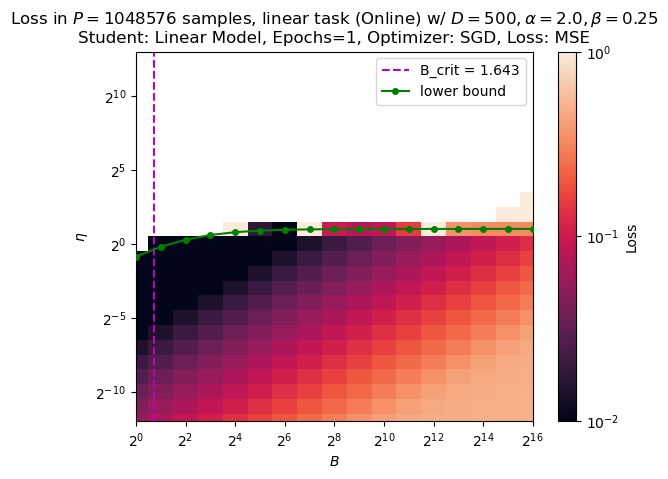

In [ ]:
experiment_cfg = experiments[exp_name]

final_errors = collect_test_errors('linear_teacher_P1048576_epochs1')
plot_heatmap_with_theory_curve(
    final_errors,
    batch_sizes,
    etas,
    experiment_cfg.plot_title(),
    metric_extractor=_final_error_extractor,
    lower_bound=lower_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

Again, recall that to get temp-space you need to pass `use_ratio_axis=True`

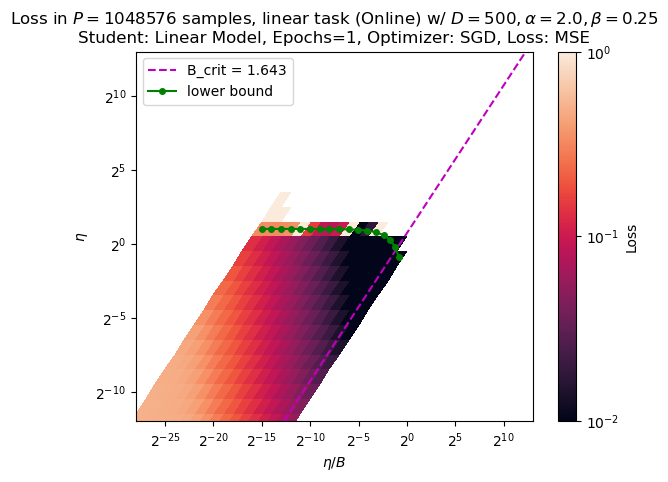

In [ ]:
plot_heatmap_with_theory_curve(
    final_errors,
    batch_sizes,
    etas,
    experiment_cfg.plot_title(),
    use_ratio_axis=True,
    metric_extractor=_final_error_extractor,
    lower_bound=lower_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

## Training curves

One can plot all training curves using `plot_all_loss_curves` (see its docstrings and signature for how to use)

Note: the order of batch or η in the legend is not fixed -- could be (b, η) or (η, b) based on sizes)

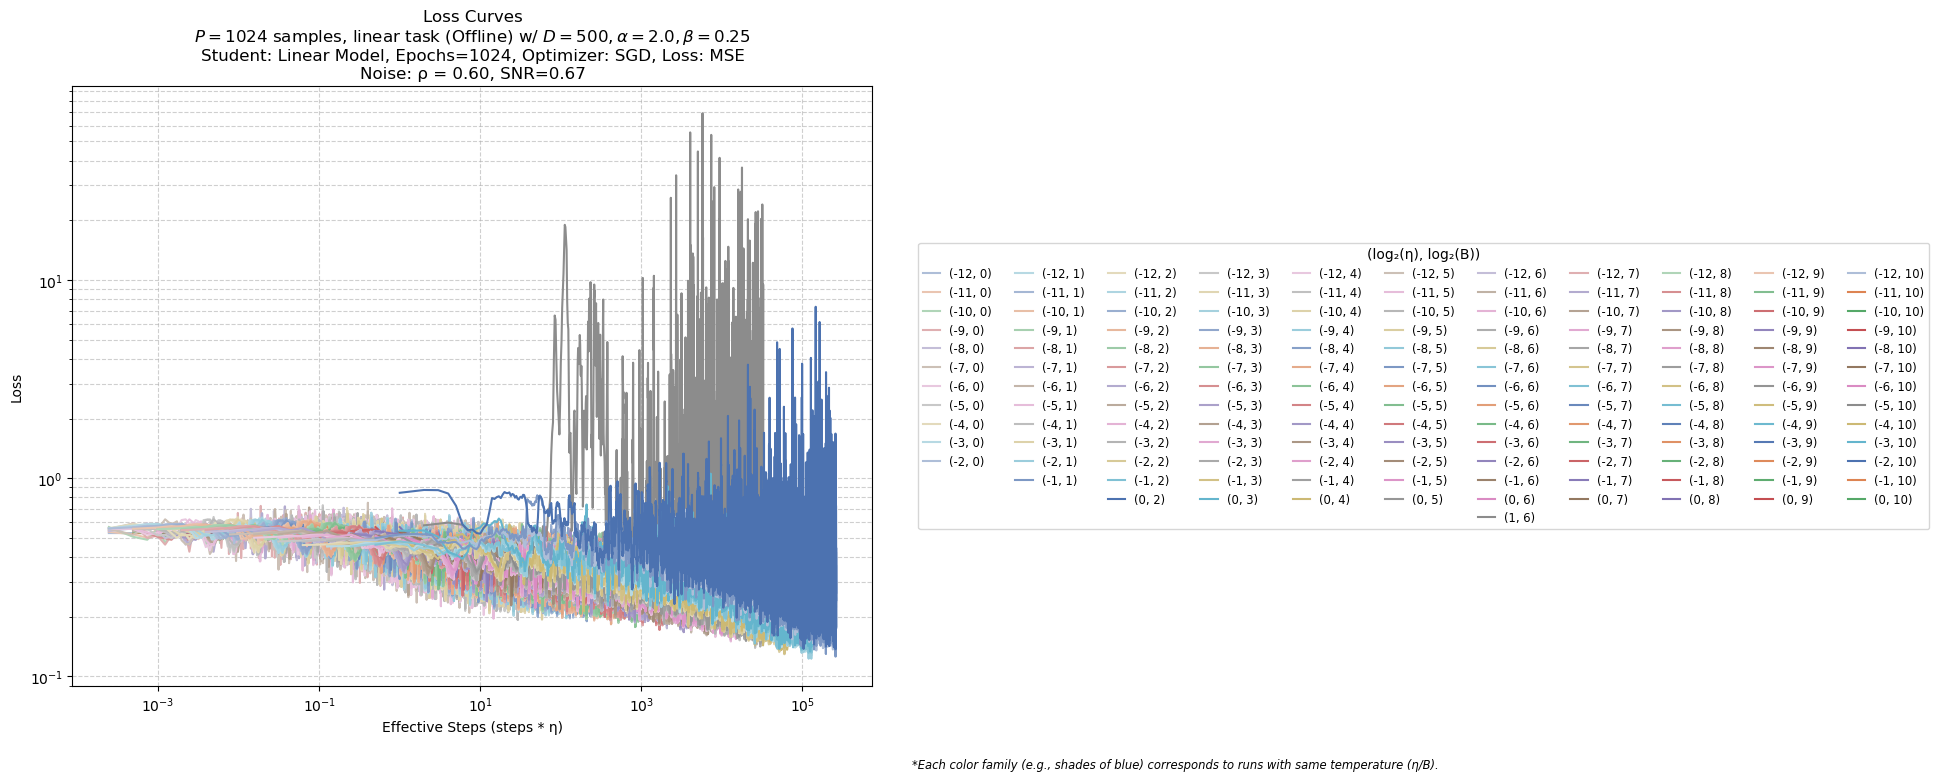

In [ ]:
plot_all_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
);

For particular temperatures, etas or batch size, use the `plot_loss_curves`. The docstring is extensive but relevant parameter is:

- `group_by`: `"B"`, `"eta"`, or `"temp"` to choose whether each curve corresponds to a batch size, learning rate, or η/B temperature.
- `group_values`: optional list restricting which groups to plot. If not selected all values for the `group_by` are plotted.
- X-axis tweaks:
  - `use_eff_steps=True` → plot steps × η (effective steps).
  - `use_samples_seen=True` → plot steps × batch size (samples seen).
  - Leave both False for raw step count.
- Scales: pass `x_scale="log"` or `y_scale="log"` to change axis scaling.

In [ ]:
# Recall we have all batches, η and temperatures precomputed already
print('batches:', batch_sizes, '\n\n η:', etas,'\n\n temps:', all_temps) 

batches: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536] 

 η: [0.000244140625, 0.00048828125, 0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0, 1024.0, 2048.0, 4096.0, 8192.0] 

 temps: [3.72529030e-09 7.45058060e-09 1.49011612e-08 2.98023224e-08
 5.96046448e-08 1.19209290e-07 2.38418579e-07 4.76837158e-07
 9.53674316e-07 1.90734863e-06 3.81469727e-06 7.62939453e-06
 1.52587891e-05 3.05175781e-05 6.10351562e-05 1.22070312e-04
 2.44140625e-04 4.88281250e-04 9.76562500e-04 1.95312500e-03
 3.90625000e-03 7.81250000e-03 1.56250000e-02 3.12500000e-02
 6.25000000e-02 1.25000000e-01 2.50000000e-01 5.00000000e-01
 1.00000000e+00 2.00000000e+00 4.00000000e+00 8.00000000e+00
 1.60000000e+01 3.20000000e+01 6.40000000e+01 1.28000000e+02
 2.56000000e+02 5.12000000e+02 1.02400000e+03 2.04800000e+03
 4.09600000e+03 8.19200000e+03]


Note: Even though we have excised all runs with losses exceeding 100, it is possible to still have divergent runs -- e.g. large batch sizes with very few iterations

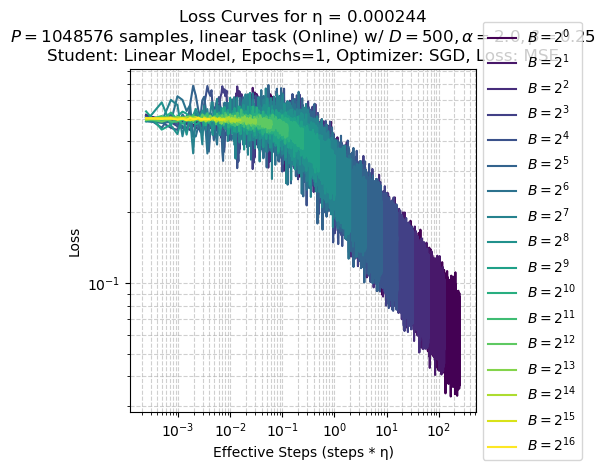

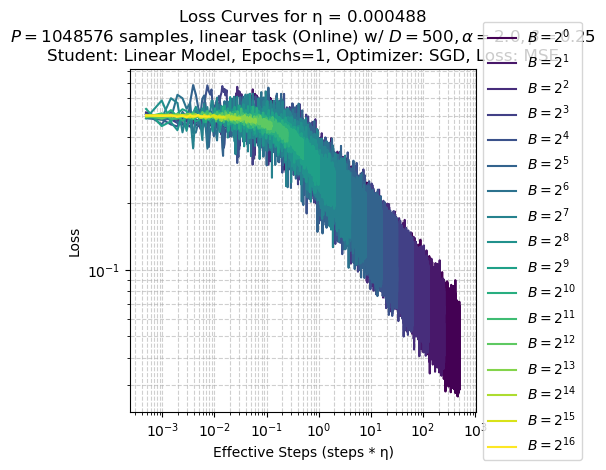

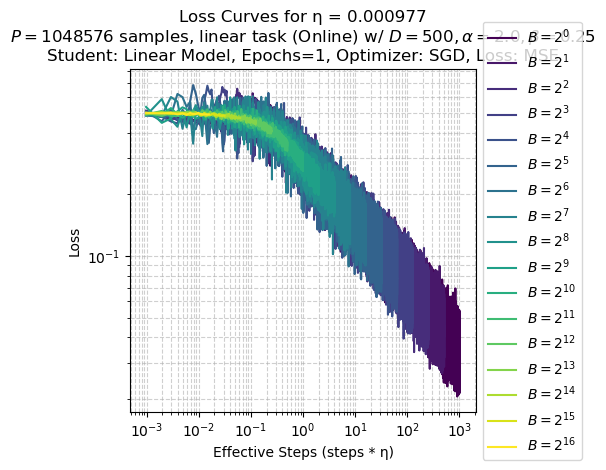

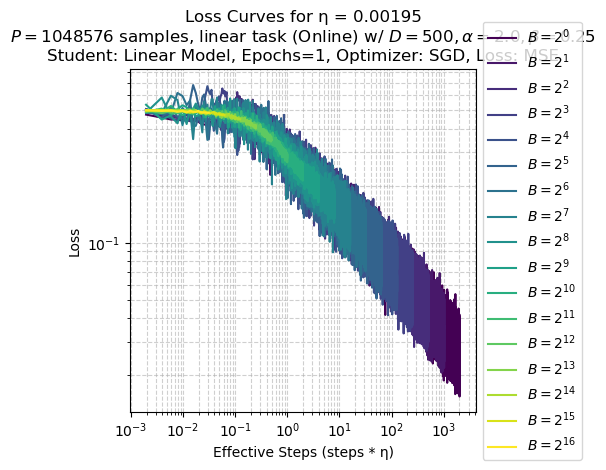

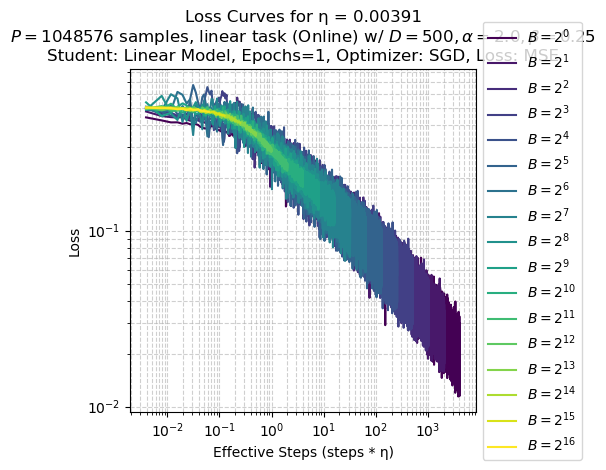

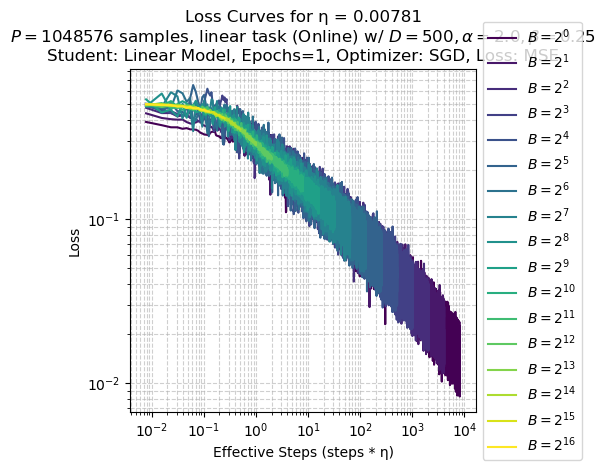

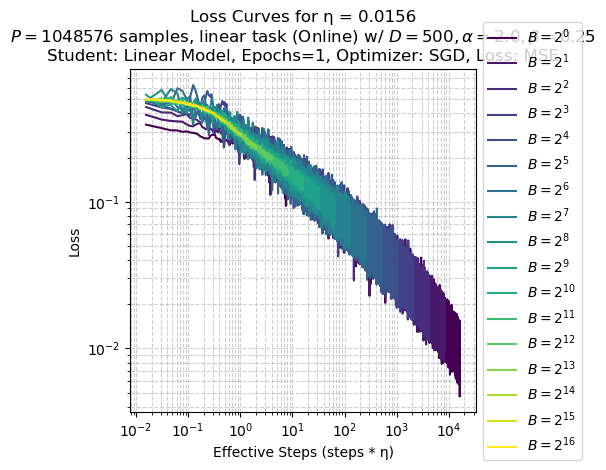

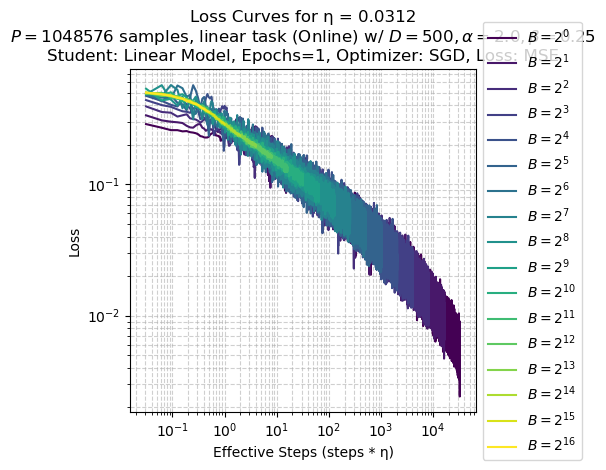

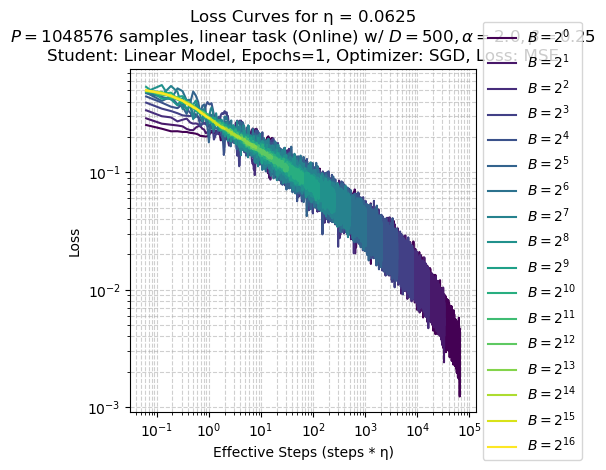

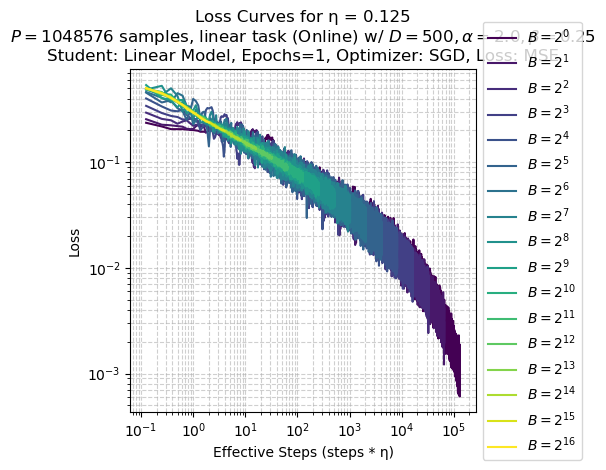

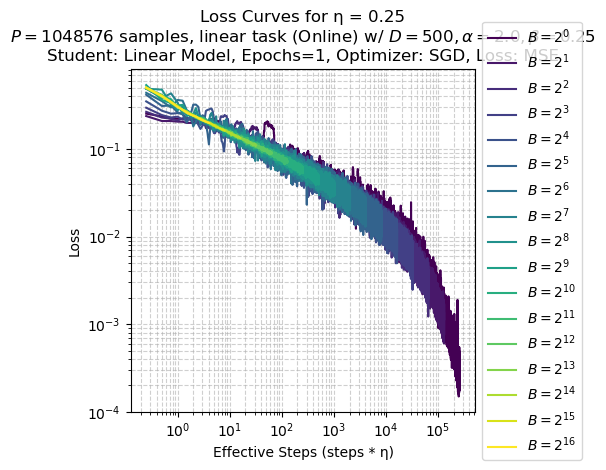

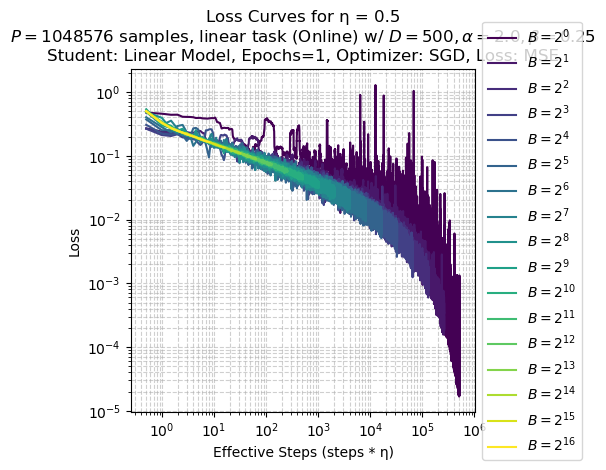

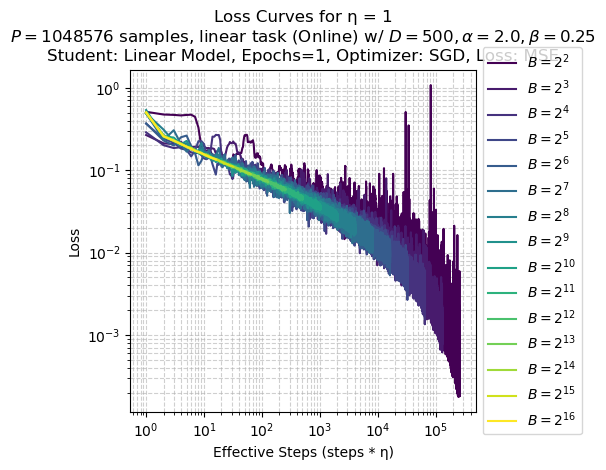

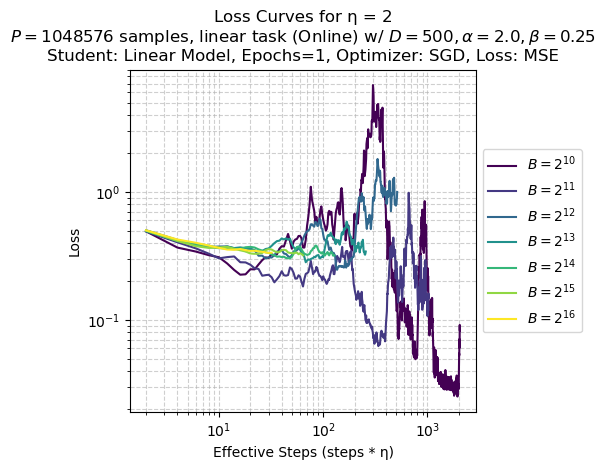

In [ ]:
experiment_cfg = experiments[exp_name]
loss_dict = loss_dicts[exp_name]

# Filter out all runs where loss exceeds 100 at any point
loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)

plot_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment_cfg.plot_title(),
    group_by="eta",
    # group_values=all_temps[-2],
    use_eff_steps=True,
    x_scale="log",
    cmap="viridis",
)